# Practical 2: Feedforward Neural Network with Keras and TensorFlow

**Aim:** Implement a feedforward (fully connected) neural network using Keras and TensorFlow, train it with Stochastic Gradient Descent (SGD), evaluate it, and plot the training loss and accuracy.

**Dataset:** MNIST handwritten digits (default) or CIFAR-10 (switch in Step b). Both are read from the local `datasets` folder, no internet needed.

**Steps (as per syllabus):**
- a. Import the necessary packages
- b. Load the training and testing data (MNIST / CIFAR-10)
- c. Define the network architecture using Keras
- d. Train the model using SGD
- e. Evaluate the network
- f. Plot the training loss and accuracy

Every step has small "inspect" cells. Run them and read the output: they show exactly what the data and the model look like at that point.

## Step a: Import the necessary packages

- `numpy` : arrays and maths
- `matplotlib` : plots
- `tensorflow` : the deep learning engine (tensors, gradients, training on CPU/GPU)
- `keras` : the high level API on top of TensorFlow to define layers and models quickly
- `sklearn.metrics` : confusion matrix and classification report for evaluation

In [1]:
# ---------------------------------------------------------------
# Common setup: imports, reproducibility, and offline data folder
# ---------------------------------------------------------------
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TensorFlow INFO/WARNING logs so outputs stay readable

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

# Fix the random seeds (Python, NumPy, TensorFlow) so every run gives similar numbers.
# This makes it easy to compare results between students.
keras.utils.set_random_seed(42)

# All data is read from the local "datasets" folder that sits next to this notebook.
# Nothing is downloaded from the internet.
DATA_DIR = Path("datasets")
MODEL_DIR = Path("models")
assert DATA_DIR.exists(), "datasets folder not found - open this notebook from the practicals folder"

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)
print("NumPy version     :", np.__version__)
print("GPU available     :", len(tf.config.list_physical_devices("GPU")) > 0, "(CPU is fine for these practicals)")

2026-09-27 21:37:02.138382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790525222.147435   13262 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790525222.150606   13262 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1790525222.158047   13262 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790525222.158060   13262 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790525222.158061   13262 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.1
Keras version     : 3.15.1
NumPy version     : 2.1.3
GPU available     : False (CPU is fine for these practicals)


2026-09-27 21:37:03.894606: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Step b: Load the training and testing data

Choose the dataset here. `"mnist"` is the default (28x28 grayscale digits).
Set it to `"cifar10"` to see how a plain feedforward network struggles on colour photos (32x32x3).

In [2]:
DATASET = "mnist"      # "mnist" or "cifar10"

if DATASET == "mnist":
    data = np.load(DATA_DIR / "mnist.npz")
    class_names = [str(i) for i in range(10)]
else:
    data = np.load(DATA_DIR / "cifar10.npz")
    class_names = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

# An .npz file is a zip of several numpy arrays. List what is inside:
print("Arrays inside the file:", list(data.keys()))

x_train, y_train = data["x_train"], data["y_train"].reshape(-1)
x_test,  y_test  = data["x_test"],  data["y_test"].reshape(-1)

Arrays inside the file: ['x_test', 'x_train', 'y_train', 'y_test']


### Inspect the raw data

In [3]:
# Shapes tell us: (number of images, height, width[, channels])
print("x_train shape:", x_train.shape, "| y_train shape:", y_train.shape)
print("x_test  shape:", x_test.shape,  "| y_test  shape:", y_test.shape)

# Pixels are stored as unsigned 8-bit integers (0 = black, 255 = white)
print("pixel dtype  :", x_train.dtype)
print("pixel range  :", x_train.min(), "to", x_train.max())
print("label dtype  :", y_train.dtype, "| unique labels:", np.unique(y_train))

x_train shape: (60000, 28, 28) | y_train shape: (60000,)
x_test  shape: (10000, 28, 28) | y_test  shape: (10000,)
pixel dtype  : uint8
pixel range  : 0 to 255
label dtype  : uint8 | unique labels: [0 1 2 3 4 5 6 7 8 9]


In [4]:
import numpy as np

# Load each individual file from your directory path
x_train = np.load('datasets/mnist/x_train.npy')
y_train = np.load('datasets/mnist/y_train.npy')
x_test = np.load('datasets/mnist/x_test.npy')
y_test = np.load('datasets/mnist/y_test.npy')

# Shapes tell us: (number of images, height, width[, channels])
print("x_train shape:", x_train.shape, "| y_train shape:", y_train.shape)
print("x_test  shape:", x_test.shape,  "| y_test  shape:", y_test.shape)

# Pixels are stored as unsigned 8-bit integers (0 = black, 255 = white)
print("pixel dtype  :", x_train.dtype)
print("pixel range  :", x_train.min(), "to", x_train.max())
print("label dtype  :", y_train.dtype, "| unique labels:", np.unique(y_train))

x_train shape: (60000, 28, 28) | y_train shape: (60000,)
x_test  shape: (10000, 28, 28) | y_test  shape: (10000,)
pixel dtype  : uint8
pixel range  : 0 to 255
label dtype  : uint8 | unique labels: [0 1 2 3 4 5 6 7 8 9]


In [5]:
# Look at the actual numbers of one image (for MNIST: a 28x28 grid of pixel values)
# Non-zero values form the shape of the digit.
sample = x_train[0]
print("Label of first image:", class_names[y_train[0]])
if DATASET == "mnist":
    np.set_printoptions(linewidth=200)
    print(sample)
else:
    print("First 4x4 pixels of the red channel:\n", sample[:4, :4, 0])

Label of first image: 5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 25

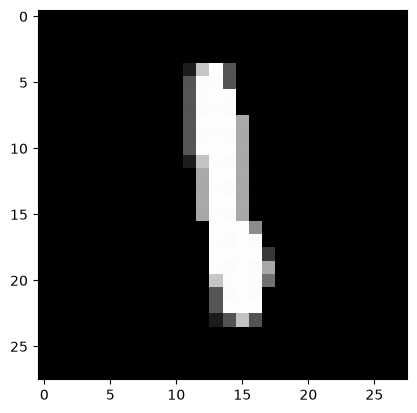

In [6]:
plt.imshow(x_train[200], cmap='gray')

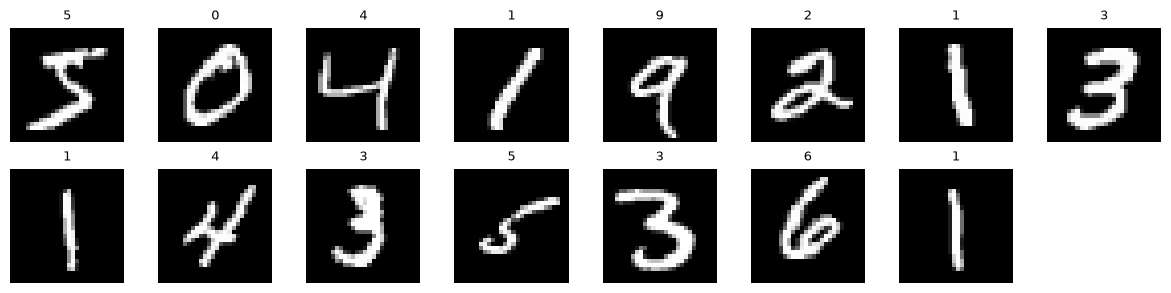

In [7]:
# Show the first 15 images with their labels
plt.figure(figsize=(12, 3))
for i in range(15):
    plt.subplot(2, 8, i + 1)
    plt.imshow(x_train[i], cmap="gray" if DATASET == "mnist" else None)
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

         0: 5923
         1: 6742
         2: 5958
         3: 6131
         4: 5842
         5: 5421
         6: 5918
         7: 6265
         8: 5851
         9: 5949


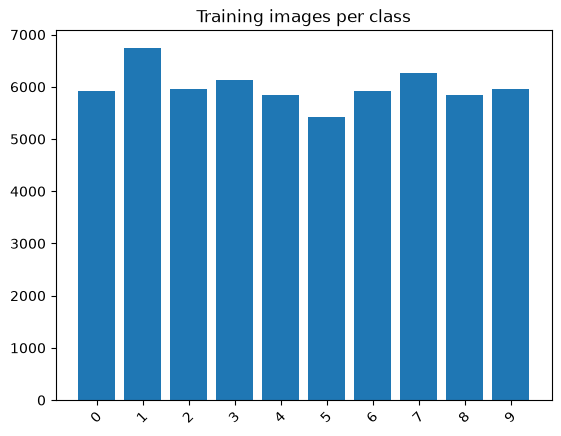

In [8]:
# Class distribution: are all classes roughly equally represented?
# A balanced dataset means plain accuracy is a fair metric.
counts = np.bincount(y_train)
for name, c in zip(class_names, counts):
    print(f"{name:>10}: {c}")

plt.bar(class_names, counts)
plt.title("Training images per class")
plt.xticks(rotation=45)
plt.show()

### Preprocess the data

1. **Flatten**: a feedforward (Dense) network only accepts a 1-D vector per sample, so each image becomes a vector of 784 (28x28) or 3072 (32x32x3) numbers. The network loses the 2-D structure of the image; this is exactly the limitation CNNs fix in Practical 3.
2. **Scale**: divide by 255 so every input is in [0, 1]. Small, similar ranged inputs make gradient descent stable.
3. **One-hot encode labels**: label `3` becomes `[0,0,0,1,0,0,0,0,0,0]`, which matches the 10 softmax outputs and the `categorical_crossentropy` loss.

In [9]:
num_features = int(np.prod(x_train.shape[1:]))   # 784 for MNIST, 3072 for CIFAR-10
num_classes = 10

x_train_flat = x_train.reshape(len(x_train), num_features).astype("float32") / 255.0
x_test_flat  = x_test.reshape(len(x_test),  num_features).astype("float32") / 255.0

y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes)

print("Flattened train shape:", x_train_flat.shape)
print("Value range after scaling:", x_train_flat.min(), "to", x_train_flat.max())
print("Original label:", y_train[0], "-> one-hot:", y_train_oh[0])

Flattened train shape: (60000, 784)
Value range after scaling: 0.0 to 1.0
Original label: 5 -> one-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Step c: Define the network architecture using Keras

Architecture (input -> hidden -> hidden -> output):

| Layer | Units | Activation | Why |
|---|---|---|---|
| Input | 784 | - | one value per pixel |
| Dense | 128 | ReLU | learns combinations of pixels |
| Dense | 64 | ReLU | learns combinations of those combinations |
| Dense | 10 | Softmax | one probability per class, all 10 sum to 1 |

Every neuron computes `output = activation(W . x + b)`.

In [10]:
model = keras.Sequential([
    keras.Input(shape=(num_features,)),
    layers.Dense(128, activation="relu", name="hidden_1"),
    layers.Dense(64, activation="relu", name="hidden_2"),
    layers.Dense(num_classes, activation="softmax", name="output"),
], name="feedforward_nn")

model.summary()

Model: "feedforward_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Inspect: verify the parameter count by hand

In [11]:
# A Dense layer with n_in inputs and n_out neurons has n_in*n_out weights + n_out biases.
def dense_params(n_in, n_out):
    return n_in * n_out + n_out

p1 = dense_params(num_features, 128)
p2 = dense_params(128, 64)
p3 = dense_params(64, 10)
print(f"hidden_1: {num_features}*128 + 128 = {p1}")
print(f"hidden_2: 128*64 + 64 = {p2}")
print(f"output  : 64*10 + 10 = {p3}")
print("Total by hand :", p1 + p2 + p3)
print("Total by Keras:", model.count_params())

hidden_1: 784*128 + 128 = 100480
hidden_2: 128*64 + 64 = 8256
output  : 64*10 + 10 = 650
Total by hand : 109386
Total by Keras: 109386


In [ ]:
# Look inside each layer: the weight matrix W and bias vector b.
# Weights start as small random numbers (Glorot uniform), biases start at zero.
for layer in model.layers:
    W, b = layer.get_weights()
    print(f"{layer.name:>9}: W shape {W.shape}, b shape {b.shape}, "
          f"W mean {W.mean():+.4f}, W std {W.std():.4f}, b all zero: {np.all(b == 0)}")

In [ ]:
# Forward pass on one image BEFORE training.
# The untrained network gives roughly equal probability (about 0.1) to every class: it is guessing.
probs_before = model.predict(x_train_flat[:1], verbose=0)[0]
print("True label:", class_names[y_train[0]])
for name, p in zip(class_names, probs_before):
    print(f"  P({name}) = {p:.3f}")
print("Sum of probabilities:", probs_before.sum())

## Step d: Train the model using SGD

- **Optimizer:** `SGD` (Stochastic Gradient Descent). "Stochastic" because each update uses a small random batch instead of the full dataset.
  - `learning_rate=0.01`: size of each step down the loss surface.
  - `momentum=0.9`: keeps 90% of the previous step's direction, which smooths and speeds up descent.
- **Loss:** `categorical_crossentropy`, the standard loss for multi-class classification with one-hot labels.
- **Metric:** `accuracy`, only for us to read; the optimizer minimises the loss, not accuracy.
- **batch_size=128:** 128 images per weight update.
- **validation_split=0.1:** the last 10% of training data is held out to check for overfitting after each epoch.

In [ ]:
EPOCHS = 10
BATCH_SIZE = 128

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# How many weight updates happen in one epoch?
n_train = int(len(x_train_flat) * 0.9)
print("Training samples used:", n_train)
print("Weight updates per epoch:", int(np.ceil(n_train / BATCH_SIZE)))

In [ ]:
history = model.fit(
    x_train_flat, y_train_oh,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

In [ ]:
# The History object stores one value per epoch for every loss/metric.
print("Recorded keys:", list(history.history.keys()))
for e in range(EPOCHS):
    h = history.history
    print(f"epoch {e+1:2d}: loss {h['loss'][e]:.4f}  acc {h['accuracy'][e]:.4f}  "
          f"val_loss {h['val_loss'][e]:.4f}  val_acc {h['val_accuracy'][e]:.4f}")

In [ ]:
# The weights have changed after training. Compare statistics with the untrained values above.
for layer in model.layers:
    W, b = layer.get_weights()
    print(f"{layer.name:>9}: W mean {W.mean():+.4f}, W std {W.std():.4f}, b mean {b.mean():+.4f}")

## Step e: Evaluate the network

`model.evaluate` runs the test set (images the network has never seen) and returns the test loss and accuracy.
Then we look deeper: individual predictions, the confusion matrix and per-class precision/recall.

In [ ]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test_oh, verbose=0)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

In [ ]:
# Predictions are probabilities; argmax picks the class with the highest probability.
probs = model.predict(x_test_flat, verbose=0)
y_pred = probs.argmax(axis=1)

print("Probabilities for the first test image:", np.round(probs[0], 3))
print("Predicted class:", class_names[y_pred[0]], "| True class:", class_names[y_test[0]])
print()
print("First 20 predictions:", y_pred[:20])
print("First 20 true labels:", y_test[:20])

In [ ]:
# Confusion matrix: rows = true class, columns = predicted class.
# The diagonal holds correct predictions; off-diagonal cells show which classes get confused.
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title("Confusion matrix on test set")
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

In [ ]:
# Look at some mistakes: what did the network confuse?
wrong = np.where(y_pred != y_test)[0]
print("Number of wrong predictions:", len(wrong), "out of", len(y_test))

plt.figure(figsize=(12, 3))
for i, idx in enumerate(wrong[:12]):
    plt.subplot(2, 6, i + 1)
    plt.imshow(x_test[idx], cmap="gray" if DATASET == "mnist" else None)
    plt.title(f"true {class_names[y_test[idx]]}\npred {class_names[y_pred[idx]]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step f: Plot the training loss and accuracy

- Both curves going down (loss) / up (accuracy) together means the model is learning well.
- If training accuracy keeps rising while validation accuracy flattens or falls, the model is starting to **overfit** (memorising the training data).

In [ ]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history["loss"], "o-", label="training loss")
plt.plot(epochs_range, history.history["val_loss"], "s-", label="validation loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history["accuracy"], "o-", label="training accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], "s-", label="validation accuracy")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Accuracy"); plt.legend()

plt.tight_layout()
plt.show()

## Try it yourself (optional)

1. Set `momentum=0.0` in Step d and retrain. Plain SGD converges more slowly; compare the curves.
2. Change `learning_rate` to `0.1` and to `0.001`. Which one is too fast, which is too slow?
3. Switch `DATASET = "cifar10"` in Step b and rerun everything. A feedforward network reaches only about 40-50% on CIFAR-10 because flattening destroys the spatial structure of the image. Practical 3 fixes this with a CNN.

## Conclusion

We built a feedforward neural network in Keras, trained it with SGD, evaluated it on unseen test data, and plotted the loss and accuracy curves. On MNIST a small network with two hidden layers reaches about 97% test accuracy.